# Coupled Cabin Cooldown and Battery Cooling: A Shared Capacity Study

## 1. Motivation
## 2. Scenario Definition
## 3. Model Overview
## 4. Assumptions
## 5. Governing Equations
## 6. Numerical Implementation
## 7. Results
## 8. Discussion
## 9. Limitations and Future Work

## 1. Motivation

In electric vehicles, the HVAC system often serves multiple thermal management functions. During high ambient conditions, the system may be required to simultaneously:

- cool the passenger cabin to maintain comfort
- manage battery temperature to protect performance and longevity

Both of these functions ultimately rely on a limited thermal resource: the cooling capacity available from the HVAC system.

During hot-soak conditions, aggressive cabin cooldown can temporarily consume most of the available cooling capacity. This raises an important system-level question:

How does prioritizing cabin comfort during transient cooldown affect battery thermal behavior?

This notebook extends the previous cabin cooldown model by introducing a shared cooling capacity constraint between cabin cooling and battery cooling.

The goal is to explore how thermal resources are distributed between subsystems during transient events and to illustrate the resulting trade-offs between passenger comfort and battery thermal management.

## 2. Scenario Definition

The simulation considers a hot-soak vehicle scenario where both the cabin and the battery begin at elevated temperatures.

### Initial Conditions

- Ambient temperature: 40°C
- Cabin air initial temperature: 60°C
- Cabin interior mass temperature: 60°C
- Cabin setpoint temperature: 22°C
- Battery initial temperature: 45°C

### Operating Conditions

- Vehicle is assumed to be in steady driving conditions
- Battery heat generation is approximated using constant current
- Cabin cooling follows a bang-bang strategy until the setpoint is reached

### Shared Cooling Capacity

The HVAC system is assumed to have a finite cooling capacity:

$$
Q_{total,max}
$$

This capacity must be shared between:

- cabin cooling
- battery cooling

In this study, **cabin cooling is given priority during transient cooldown**, with remaining capacity allocated to battery cooling if available.

### Simulation Duration

- Total simulation time: 20 minutes
- Time step: 1–2 seconds

This setup allows the model to capture the transient competition for cooling resources during the initial cabin cooldown phase.

## 3. Model Overview

The thermal system is represented using three lumped thermal nodes:

| Node | Description |
|-----|-------------|
| $T_a$ | Cabin air temperature |
| $T_i$ | Cabin interior thermal mass temperature |
| $T_b$ | Battery temperature |

Heat transfer interactions include:

- ambient heat gain into the cabin
- thermal exchange between cabin air and interior mass
- battery heat generation due to electrical current
- cooling capacity distributed between cabin and battery

The key addition in this model is a **shared cooling capacity constraint**.

At each time step:

$$
Q_{cool,cabin} + Q_{cool,batt} \le Q_{total,max}
$$

Cabin cooling demand is satisfied first while the cabin temperature exceeds the setpoint. Any remaining cooling capacity may be allocated to battery cooling if the battery temperature exceeds a threshold.

This simplified representation captures an important real-world system interaction: **thermal resource competition between passenger comfort and battery protection.**

## 4. Assumptions

To maintain transparency and interpretability, several simplifying assumptions are used in this model. The objective is to capture the dominant thermal interactions while keeping the system representation simple and explainable.

### Thermal System Representation

The vehicle thermal system is represented using three lumped thermal nodes:

- Cabin air temperature, $T_a$
- Cabin interior thermal mass temperature, $T_i$
- Battery temperature, $T_b$

Each node is modeled using a lumped thermal capacitance.

### Cabin Thermal Model

The cabin model consists of two thermal states:

1. Cabin air
2. Cabin interior mass

Heat transfer interactions include:

- ambient heat gain into the cabin
- thermal exchange between cabin air and interior surfaces
- active cooling applied by the HVAC system

Cabin cooling follows a **bang-bang control strategy**, where maximum cooling capacity is applied until the cabin temperature reaches the setpoint.

### Battery Thermal Model

Battery heat generation is approximated using a simplified $I^2R$ formulation:

$$
Q_{gen} = I^2 R_{int}
$$

where $I$ represents a constant drive current during steady driving.

The battery is treated as a lumped thermal mass with no spatial temperature gradients.

### Shared Cooling Capacity Constraint

The HVAC system is assumed to provide a finite total cooling capacity:

$$
Q_{total,max}
$$

This capacity must be shared between cabin cooling and battery cooling:

$$
Q_{cool,cabin} + Q_{cool,batt} \le Q_{total,max}
$$

In this study, **cabin cooling is prioritized during transient cabin cooldown**. Any remaining cooling capacity may be allocated to battery cooling if the battery temperature exceeds a defined threshold.

### Cooling Allocation Strategy

Cooling allocation follows a simple priority rule:

1. Cabin cooling demand is satisfied first while the cabin temperature exceeds the setpoint.
2. Remaining cooling capacity is allocated to the battery when battery temperature exceeds a threshold value.

### Thermal Priority Philosophy

In real vehicle thermal management systems, cooling resources are typically allocated according to the thermal risk state of different subsystems.

Three conceptual operating regimes are often considered:

1. **Comfort-priority regime** – When battery temperature is within a safe operating range, the HVAC system prioritizes cabin comfort during transient cooldown events.

2. **Shared-priority regime** – As battery temperature rises toward elevated levels, cooling capacity may be distributed between cabin comfort and battery thermal management.

3. **Protection-priority regime** – If battery temperature approaches protection limits, cooling resources must prioritize battery protection, even at the expense of cabin comfort.

The present study focuses on the **comfort-priority regime**, where cabin cooldown is assumed to dominate cooling demand immediately after a hot-soak event. Battery cooling is therefore allocated only after cabin cooling demand is satisfied within the shared cooling capacity constraint.

Future extensions of this model may introduce **dynamic priority shifting**, where cooling allocation changes as battery temperature approaches defined protection thresholds.

### Simplifications

The following effects are intentionally excluded from this model:

- solar radiation heat load
- air infiltration through body leakage or exhausters
- detailed refrigerant cycle dynamics
- low-temperature loop interactions with e-motors or power electronics
- condenser and radiator airflow coupling

These simplifications allow the model to focus specifically on the **interaction between cabin comfort and battery thermal management under a shared cooling capacity constraint**.

## 5. Governing Equations

The system is modeled using simplified energy balance equations for each thermal node.

### 5.1 Cabin Air Energy Balance

Cabin air temperature is influenced by:

- ambient heat gain
- thermal exchange with interior surfaces
- active HVAC cooling

The governing equation is:

$$
C_a \frac{dT_a}{dt} = Q_{amb \rightarrow a} + Q_{i \leftrightarrow a} - Q_{cool,cabin}
$$

where

- $C_a$ = effective cabin air thermal capacitance  
- $Q_{amb \rightarrow a}$ = ambient heat gain into cabin air  
- $Q_{i \leftrightarrow a}$ = heat transfer between interior mass and cabin air  
- $Q_{cool,cabin}$ = cooling applied to the cabin

Ambient heat gain is approximated as:

$$
Q_{amb \rightarrow a} = UA_a (T_{amb} - T_a)
$$

Interior-air heat exchange is modeled as:

$$
Q_{i \leftrightarrow a} = h_{ia}A_{ia}(T_i - T_a)
$$

---

### 5.2 Cabin Interior Thermal Mass

Interior surfaces exchange heat with cabin air but do not directly interact with ambient in this simplified model.

$$
C_i \frac{dT_i}{dt} = -Q_{i \leftrightarrow a}
$$

where

- $C_i$ = effective interior thermal capacitance

---

### 5.3 Battery Thermal Model

Battery heat generation is approximated using a simplified electrical loss model:

$$
Q_{gen} = I^2 R_{int}
$$

Battery temperature evolves according to:

$$
C_b \frac{dT_b}{dt} = Q_{gen} - Q_{passive} - Q_{cool,batt}
$$

where

- $C_b$ = battery thermal capacitance  
- $Q_{passive}$ = passive heat rejection to ambient

Passive heat rejection is approximated as:

$$
Q_{passive} = k_b (T_b - T_{amb})
$$

---

### 5.4 Shared Cooling Capacity Constraint

Cabin cooling and battery cooling share a common thermal capacity limit:

$$
Q_{cool,cabin} + Q_{cool,batt} \le Q_{total,max}
$$

Cooling allocation follows a **cabin-priority strategy**:

1. Cabin cooling demand is satisfied first while $T_a > T_{set}$.
2. Remaining cooling capacity is allocated to the battery if $T_b$ exceeds a threshold.

---

### 5.5 Compressor Power

Compressor electrical power is estimated from the total thermal load served by the HVAC system:

$$
P_{comp} = \frac{Q_{cool,cabin} + Q_{cool,batt}}{COP(T_{amb})}
$$

The coefficient of performance is represented using a simplified ambient-temperature-dependent function:

$$
COP = COP(T_{amb})
$$

This relationship captures the reduction in HVAC efficiency at higher ambient temperatures.

## 6. Numerical Implementation

The coupled thermal system is simulated using a forward-Euler time integration scheme with a fixed time step $\Delta t$.

At each time step, the following sequence is applied:

1. Compute cabin heat transfer terms:
   - ambient heat gain into cabin air
   - interior-to-air thermal exchange

2. Compute battery heat generation and passive heat rejection

3. Determine cabin cooling demand using bang-bang control

4. Determine battery cooling demand based on battery temperature threshold

5. Allocate total cooling capacity according to a cabin-priority rule:

   - cabin cooling demand is satisfied first
   - remaining cooling capacity is assigned to the battery

6. Update thermal states:
   - cabin air temperature
   - interior thermal mass temperature
   - battery temperature

7. Compute compressor power and cumulative auxiliary energy consumption

This approach provides a simple and transparent way to visualize transient competition for thermal resources between cabin comfort and battery cooling.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Scenario inputs
# -----------------------------
T_amb = 40.0          # degC
T_set = 22.0          # degC

T_a0 = 60.0           # cabin air initial (degC)
T_i0 = 60.0           # interior mass initial (degC)
T_b0 = 44.0           # battery initial (degC)

t_end_min = 20.0      # minutes
dt = 2.0              # seconds

# -----------------------------
# 2) Thermal model parameters
# -----------------------------
cp_air = 1005.0       # J/(kg*K)

# Cabin air
m_air_eff = 2.5
C_a = m_air_eff * cp_air

# Interior mass
m_int_eff = 120.0
cp_int = 900.0
C_i = m_int_eff * cp_int

# Cabin heat transfer
UA_a = 120.0          # W/K
hA_ia = 180.0         # W/K

# Cooling limits
Q_cool_max = 5000.0   # W max cabin demand
Q_cool_maint = 0.0    # W
Q_total_max = 6500.0  # W shared total cooling capacity

# Battery parameters
C_b = 200000.0        # J/K
R_int = 0.010         # ohm
I_drive = 200.0       # A
k_b = 10.0            # W/K passive heat rejection

# Battery cooling thresholds
T_b_thresh = 45.0     # degC
T_b_target = 40.0     # degC

# -----------------------------
# 3) COP model
# -----------------------------
def COP(Tamb):
    if Tamb <= 25:
        return 3.0
    elif Tamb <= 40:
        return 3.0 - (Tamb - 25.0) * (0.8 / 15.0)
    else:
        return max(1.6, 2.2 - (Tamb - 40.0) * 0.05)

# -----------------------------
# 4) Time vector + storage
# -----------------------------
t_end = t_end_min * 60.0
t = np.arange(0, t_end + dt, dt)

T_a = np.zeros_like(t)
T_i = np.zeros_like(t)
T_b = np.zeros_like(t)

Q_cool_cabin_arr = np.zeros_like(t)
Q_cool_batt_arr = np.zeros_like(t)
P_comp = np.zeros_like(t)
E_comp_Wh = np.zeros_like(t)

T_a[0] = T_a0
T_i[0] = T_i0
T_b[0] = T_b0

# -----------------------------
# 5) Euler simulation loop
# -----------------------------
for k in range(len(t) - 1):

    # Cabin heat transfer
    Q_amb_to_a = UA_a * (T_amb - T_a[k])
    Q_i_to_a = hA_ia * (T_i[k] - T_a[k])

    # Cabin demand (bang-bang)
    if T_a[k] > T_set:
        Q_cabin_demand = Q_cool_max
    else:
        Q_cabin_demand = Q_cool_maint

    # Battery cooling demand
    if T_b[k] > T_b_thresh:
        Q_batt_demand = min(2500.0, 200.0 * (T_b[k] - T_b_target))
    else:
        Q_batt_demand = 0.0

    # Shared cooling allocation (cabin priority)
    Q_cool_cabin = min(Q_cabin_demand, Q_total_max)
    Q_remaining = Q_total_max - Q_cool_cabin
    Q_cool_batt = min(Q_batt_demand, Q_remaining)

    # Store cooling allocations
    Q_cool_cabin_arr[k] = Q_cool_cabin
    Q_cool_batt_arr[k] = Q_cool_batt

    # Battery heat generation and passive rejection
    Q_gen = (I_drive ** 2) * R_int
    Q_passive = k_b * (T_b[k] - T_amb)

    # ODEs
    dTa_dt = (Q_amb_to_a + Q_i_to_a - Q_cool_cabin) / C_a
    dTi_dt = (-Q_i_to_a) / C_i
    dTb_dt = (Q_gen - Q_passive - Q_cool_batt) / C_b

    # Update states
    T_a[k + 1] = T_a[k] + dt * dTa_dt
    T_i[k + 1] = T_i[k] + dt * dTi_dt
    T_b[k + 1] = T_b[k] + dt * dTb_dt

    # Compressor power + cumulative energy
    Q_total_used = Q_cool_cabin + Q_cool_batt
    P_comp[k] = Q_total_used / COP(T_amb)
    E_comp_Wh[k + 1] = E_comp_Wh[k] + (P_comp[k] * dt) / 3600.0

# Fill last sample for plotting
Q_cool_cabin_arr[-1] = Q_cool_cabin_arr[-2]
Q_cool_batt_arr[-1] = Q_cool_batt_arr[-2]
P_comp[-1] = P_comp[-2]

# -----------------------------
# 6) Basic output
# -----------------------------

# Cabin setpoint time
setpoint_indices = np.where(T_a <= T_set)[0]
if len(setpoint_indices) > 0:
    t_set_min = t[setpoint_indices[0]] / 60.0
    print(f"Cabin reaches setpoint at: {t_set_min:.2f} min")
else:
    print("Cabin did not reach setpoint within the simulation window.")

# Peak battery temperature
print(f"Peak battery temperature: {np.max(T_b):.2f} °C")

# Time when battery cooling first starts
batt_cooling_indices = np.where(Q_cool_batt_arr > 0)[0]
if len(batt_cooling_indices) > 0:
    t_batt_cool_start = t[batt_cooling_indices[0]] / 60.0
    print(f"Battery cooling first starts at: {t_batt_cool_start:.2f} min")
else:
    print("Battery cooling never activates within the simulation window.")

# Maximum battery cooling allocated
print(f"Maximum battery cooling allocation: {np.max(Q_cool_batt_arr):.1f} W")

# Total compressor energy
print(f"Total compressor energy over {t_end_min:.0f} min: {E_comp_Wh[-1]/1000.0:.3f} kWh")

print(f"Final battery temperature: {T_b[-1]:.2f} °C")

Cabin reaches setpoint at: 11.57 min
Peak battery temperature: 45.00 °C
Battery cooling first starts at: 9.40 min
Maximum battery cooling allocation: 1000.7 W
Total compressor energy over 20 min: 0.708 kWh
Final battery temperature: 44.99 °C


In [8]:
eps = 1.0  # W threshold to ignore tiny numerical noise

# Battery cooling start using a meaningful threshold
batt_cooling_indices = np.where(Q_cool_batt_arr > eps)[0]
if len(batt_cooling_indices) > 0:
    print(f"Battery cooling (> {eps} W) first starts at: {t[batt_cooling_indices[0]]/60:.2f} min")
else:
    print("Battery cooling never meaningfully activates.")

# First time cabin cooling is NOT at full demand
cabin_relax_indices = np.where(Q_cool_cabin_arr < Q_cool_max - eps)[0]
if len(cabin_relax_indices) > 0:
    print(f"Cabin cooling first relaxes below full demand at: {t[cabin_relax_indices[0]]/60:.2f} min")
else:
    print("Cabin cooling stays at full demand throughout.")

# Find first meaningful battery cooling index
eps = 1.0
batt_idx = np.where(Q_cool_batt_arr > eps)[0]

if len(batt_idx) > 0:
    k0 = batt_idx[0]
    print("First battery cooling index:", k0)
    print(f"Time: {t[k0]/60:.2f} min")
    print(f"T_a = {T_a[k0]:.2f} °C")
    print(f"T_b = {T_b[k0]:.2f} °C")
    print(f"Q_cool_cabin = {Q_cool_cabin_arr[k0]:.2f} W")
    print(f"Q_cool_batt = {Q_cool_batt_arr[k0]:.2f} W")
    print(f"Q_total_max = {Q_total_max:.2f} W")
    print(f"Q_cool_max = {Q_cool_max:.2f} W")
else:
    print("No meaningful battery cooling found.")

if T_a[k] > T_set and Q_total_max <= Q_cool_max:
    assert Q_cool_batt <= 1e-9, (
        f"Battery cooling should be zero during strict cabin priority, "
        f"but got {Q_cool_batt:.3f} W at t = {t[k]/60:.2f} min"
    )

Battery cooling (> 1.0 W) first starts at: 9.40 min
Cabin cooling first relaxes below full demand at: 11.57 min


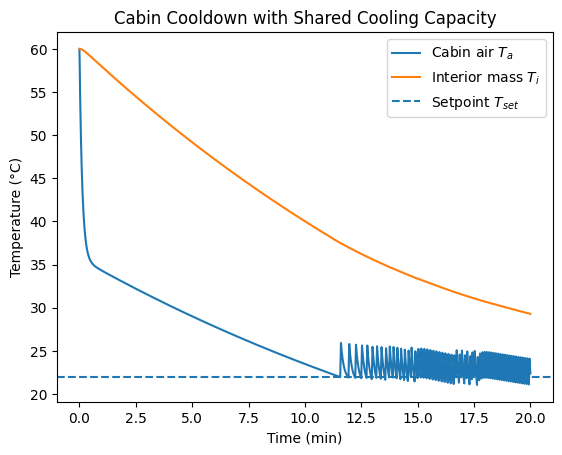

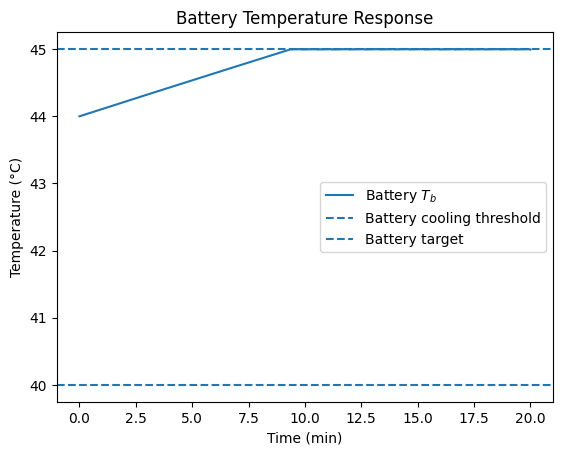

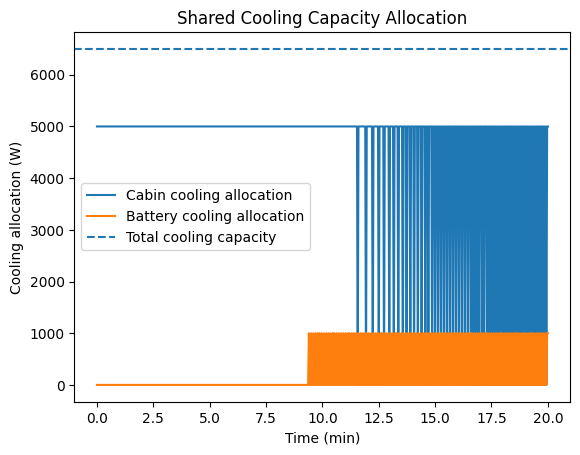

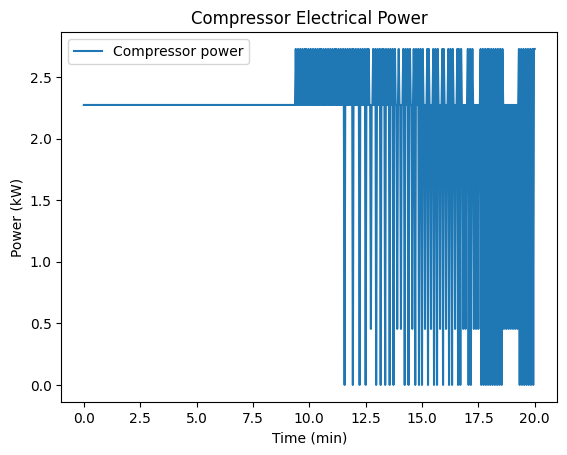

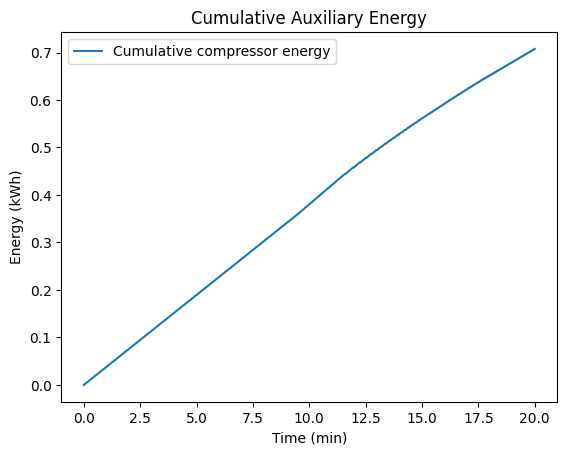

In [9]:
plt.figure()
plt.plot(t/60.0, T_a, label="Cabin air $T_a$")
plt.plot(t/60.0, T_i, label="Interior mass $T_i$")
plt.axhline(T_set, linestyle="--", label="Setpoint $T_{set}$")
plt.xlabel("Time (min)")
plt.ylabel("Temperature (°C)")
plt.title("Cabin Cooldown with Shared Cooling Capacity")
plt.legend()
plt.show()

plt.figure()
plt.plot(t/60.0, T_b, label="Battery $T_b$")
plt.axhline(T_b_thresh, linestyle="--", label="Battery cooling threshold")
plt.axhline(T_b_target, linestyle="--", label="Battery target")
plt.xlabel("Time (min)")
plt.ylabel("Temperature (°C)")
plt.title("Battery Temperature Response")
plt.legend()
plt.show()

plt.figure()
plt.plot(t/60.0, Q_cool_cabin_arr, label="Cabin cooling allocation")
plt.plot(t/60.0, Q_cool_batt_arr, label="Battery cooling allocation")
plt.axhline(Q_total_max, linestyle="--", label="Total cooling capacity")
plt.xlabel("Time (min)")
plt.ylabel("Cooling allocation (W)")
plt.title("Shared Cooling Capacity Allocation")
plt.legend()
plt.show()

plt.figure()
plt.plot(t/60.0, P_comp/1000.0, label="Compressor power")
plt.xlabel("Time (min)")
plt.ylabel("Power (kW)")
plt.title("Compressor Electrical Power")
plt.legend()
plt.show()

plt.figure()
plt.plot(t/60.0, E_comp_Wh/1000.0, label="Cumulative compressor energy")
plt.xlabel("Time (min)")
plt.ylabel("Energy (kWh)")
plt.title("Cumulative Auxiliary Energy")
plt.legend()
plt.show()